# Ridge Regularization

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.datasets import make_regression, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [46]:
x, y = make_regression(noise=30,n_features=1,n_informative=1)

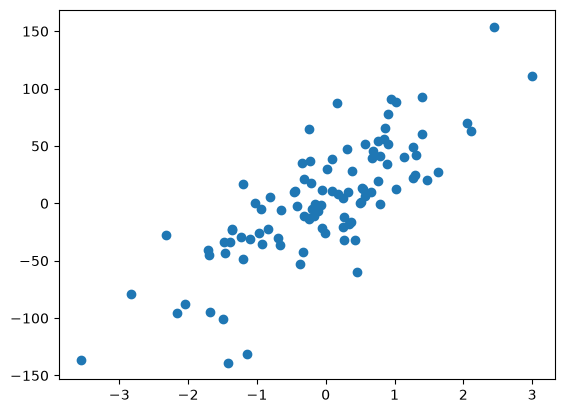

In [47]:
plt.scatter(x, y)
plt.show()

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Lienar Regression

In [49]:
lr = LinearRegression()
lr.fit(x_train, y_train)
print(lr.intercept_, lr.coef_)

5.670526324964907 [35.6254738]


In [50]:
y_pred = lr.predict(x_test)
print(r2_score(y_test, y_pred))

0.6201512661598294


### Ridge Regularization

In [61]:
R = Ridge(alpha=10)
R.fit(x_train, y_train)
print(R.intercept_, R.coef_)

5.341713226669897 [32.46519957]


In [62]:
y_pred_r = R.predict(x_test)
print(r2_score(y_test, y_pred_r))

0.6118928349949223


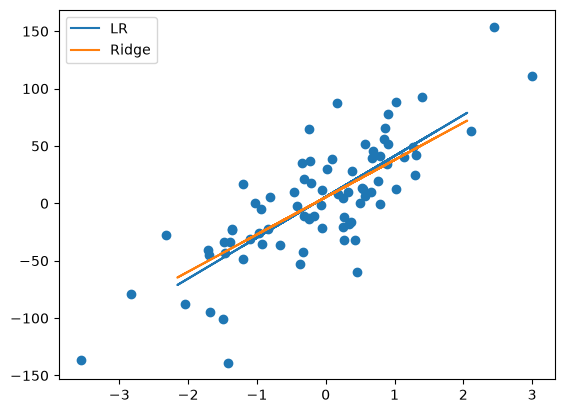

In [65]:
plt.scatter(x_train, y_train)
plt.plot(x_test, y_pred, label='LR')
plt.plot(x_test, y_pred_r, label='Ridge')

plt.legend()
plt.show()

## Ridge Regularization Class for 2D Data

In [83]:
class RidgeReg:

    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.intercept = None
        self.coef = None

    def fit(self, x_train, y_train):

        num = 0
        den = 0

        for i in range(x_train.shape[0]):
            
            num += (x_train[i]-x_train.mean())*(y_train[i]-y_train.mean())
            den += (x_train[i]-x_train.mean())*(x_train[i]-x_train.mean())

        self.coef = num/(den + self.alpha)

        self.intercept = y_train.mean() - (self.coef * x_train.mean())

        return self.intercept, self.coef

    def predict(self,x_test):

        return x_test*self.coef + self.intercept

In [84]:
rr = RidgeReg(alpha=10)
rr.fit(x_train, y_train)

(array([5.34171323]), array([32.46519957]))

In [85]:
r2_score(y_test, rr.predict(x_test))

0.6118928349949224

## Ridge Regularization Class for nD data

In [97]:
class RidgeRegN:

    def __init__(self, alpha=0.01):
        self.alpha = alpha
        self.intercept = None
        self.coef = None

    def fit(self, x_train, y_train):

        x_train = np.insert(x_train, 0, 1, axis=1)
        I = np.identity(x_train.shape[1])
        I[0][0] = 0 # lambda is multiplied only with coef

        mat = np.dot(x_train.T, y_train) @ np.linalg.inv(np.dot(x_train.T, x_train) + self.alpha * I)

        self.intercept = mat[0]
        self.coef = mat[1:]

        return self.intercept, self.coef

    def predict(self, x_test):

        return np.dot(x_test, self.coef) + self.intercept

In [98]:
x, y = load_diabetes(return_X_y=True)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [99]:
# comparison
R = Ridge(alpha=10)
R.fit(x_train, y_train)
print(R.intercept_, R.coef_, sep='\n')

153.35944595511015
[ 18.22962257  -3.27753564  65.12841688  48.21966755  16.23831513
  10.86105458 -39.20891284  41.43856828  57.95012433  39.35940115]


In [100]:
rr = RidgeRegN(alpha=10)
rr.fit(x_train, y_train)

(np.float64(153.35944595511017),
 array([ 18.22962257,  -3.27753564,  65.12841688,  48.21966755,
         16.23831513,  10.86105458, -39.20891284,  41.43856828,
         57.95012433,  39.35940115]))

## Using GD

In [125]:
class RidgeGD:

    def __init__(self, epoch=1000, alpha=0.01, learning_rate=0.01):

        self.epoch = epoch
        self.alpha = alpha
        self.lr = learning_rate
        self.intercept = None
        self.coef = None

    def fit(self, x_train, y_train):

        self.coef = np.ones(x_train.shape[1])
        self.intercept = 0

        w = np.insert(self.coef, 0, self.intercept)

        x_train = np.insert(x_train, 0, 1, axis=1)

        for i in range(self.epoch):
            reg = self.alpha*w
            w_der = (x_train.T @ x_train) @ w - (x_train.T @ y_train) + reg
            w -= self.lr * w_der

        self.intercept = w[0]
        self.coef = w[1:]

        return self.intercept, self.coef

    def predict(self, x_test):
        
        return np.dot(x_test, self.coef) + self.intercept

In [133]:
R = Ridge(alpha = 0.001, solver='sparse_cg', max_iter=500)
# sparse_cg, sag, saga uses GD, rest of all the solver uses OLS
R.fit(x_train, y_train)
print(R.intercept_, R.coef_, sep='\n')

151.34198057253573
[  38.48350477 -241.35179545  543.83517825  346.7828302  -827.70199536
  437.17374796  116.94975332  260.75926347  696.12922271   49.74344621]


In [134]:
from sklearn.linear_model import SGDRegressor
reg = SGDRegressor(penalty='l2', alpha=0.001, eta0=0.005, max_iter=500, learning_rate='constant')
reg.fit(x_train, y_train)
print(reg.intercept_, reg.coef_, sep='\n')

[151.94317911]
[  54.883888    -61.52012449  296.78123601  208.43832826   15.08640125
  -14.06223879 -155.8625573   135.83607453  240.05786888  135.039164  ]


In [135]:
rrgd = RidgeGD(alpha=0.001, learning_rate=0.005, epoch=500)
rrgd.fit(x_train, y_train)

(np.float64(151.40454755919725),
 array([  43.37183861, -192.03766574,  496.43542567,  319.37407   ,
         -64.42788084, -113.194338  , -213.9073644 ,  144.86136322,
         367.67948022,  119.56857869]))

In [136]:
# chekcing every r2 score
print('Ridge : ', r2_score(y_test, R.predict(x_test)))
print('SGD : ', r2_score(y_test, reg.predict(x_test)))
print('RidgeGD : ', r2_score(y_test, rrgd.predict(x_test)))

Ridge :  0.4534280301708902
SGD :  0.42739616758595433
RidgeGD :  0.45922493769364114
